In [1]:
import os
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
import torch
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from typing import Tuple
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import random_split
import torch.nn.functional as F
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea
from sklearn.decomposition import PCA

from ipywidgets import interactive

In [2]:
# Проверяем наличие CUDA
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Используется GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA не найдена, используется CPU")

Используется GPU: NVIDIA GeForce RTX 3060


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.2860405147075653],
        std=[0.320453405380249]
    )
])

# Dataset
trainset = datasets.FashionMNIST(
    root='./data',
    train=True, 
    download=False,
    transform=transform
)
testset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform
)
# Dataloader
train_loader = DataLoader(
    trainset, 
    batch_size=128,
    shuffle=True
)
test_loader = DataLoader(
    testset, 
    batch_size=128, 
    shuffle=True
)

In [4]:

# mean = torch.zeros(1)
# std = torch.zeros(1)
# total = 0


# for images, labels in train_loader :
#     batch_samples = images.size(0)
#     images = images.view(batch_samples, 1, -1)

#     mean += images.mean(2).sum(0)
#     std += images.std(2).sum(0)
#     total += batch_samples

# mean /= total
# std /= total

# print(f"Mean: {mean.tolist()}")
# print(f"Std:  {std.tolist()}")



In [5]:
class AutoEncoder(nn.Module):
    
    def __init__(self, img_shape, inp_dim, hidden_dim):
        super(AutoEncoder, self).__init__()
        self.img_shape = img_shape
        self.encoder = nn.Sequential(nn.Linear(inp_dim, 256),
                                     nn.ReLU(),
                                     nn.Linear(256, 128),
                                     nn.ReLU(),
                                     nn.Linear(128, hidden_dim)
                                    )
        self.decoder = nn.Sequential(nn.Linear(hidden_dim, 128),
                                     nn.ReLU(),
                                     nn.Linear(128, 256),
                                     nn.ReLU(),
                                     nn.Linear(256, inp_dim)
                                    )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(x.size(0),*self.img_shape)
    
    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)
    
    def decode(self, x_latent):
        return self.decoder(x_latent).view(*self.img_shape)


In [6]:
# constants
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
BATCH_SIZE = 128

model = AutoEncoder((1, 28, 28), 28*28, 8)
criterion = nn.MSELoss() # nn.BCELoss() 
opt = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [7]:
def train_step() -> float:
    model.train()
    
    running_loss = 0.
    for images, _ in train_loader:
        images = images.to(device)
        
        # Удаляем накопленные ранее градиенты.
        # parameter.grad = 0
        opt.zero_grad()
        
        # Делаем проход (forward pass).
        # Состояние модели `train` обеспечивает сохранение промежуточных результатов вычислений.
        # Эти сохраненные значения будут использованы ниже для вычисления градиента функции потерь.
        output = model(images)
        
        # Вычисляем функцию потерь на основе предсказания модели.
        loss = criterion(output, images)

        # Вычисляем градиент: направление, в котором функция потерь возрастает максимально быстро.
        # parameter.grad += dloss / dparameter
        loss.backward()

        # parameter += -lr * parameter.grad
        # 
        # PyTorch SGD:
        # velocity = momentum * velocity + parameter.grad
        # parameter += - lr * velocity
        opt.step()
        
        # Накапливаем статистику.
        running_loss += loss
    
    # Контекстный менеджер `torch.no_grad` позволяет отключить вычисление градиентов.
    # Вычисления, в которые входят обучаемые параметры, не имеющие отношения к сети повлияют на процесс обучения,
    # если для них будут накапливаться градиенты.
    # Экономия памяти.
    with torch.no_grad():
        train_loss = running_loss / len(train_loader)
    return train_loss.item()


def test_step() -> Tuple[float, float]:
    model.eval()

    correct_total = 0.
    running_loss = 0.
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)

            output = model(images)

            loss = criterion(output, images)
            running_loss += loss
        
    valid_loss = running_loss / len(test_loader)
    accuracy = correct_total / len(test_loader.dataset)
    return valid_loss.item(), accuracy

In [8]:
train_losses = []
valid_losses = []
valid_accs = []

epochs = 100
model.to(device)

for _ in (pbar := tqdm(range(epochs))):
    train_loss = train_step()
    valid_loss, valid_acc = test_step()
    
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)
    
    pbar.set_description(f'Avg. train/valid loss: {train_loss:.4f}/{valid_loss:.4f}')

Avg. train/valid loss: 0.1417/0.1444: 100%|██████████| 100/100 [07:32<00:00,  4.52s/it]


Text(0, 0.5, 'Loss')

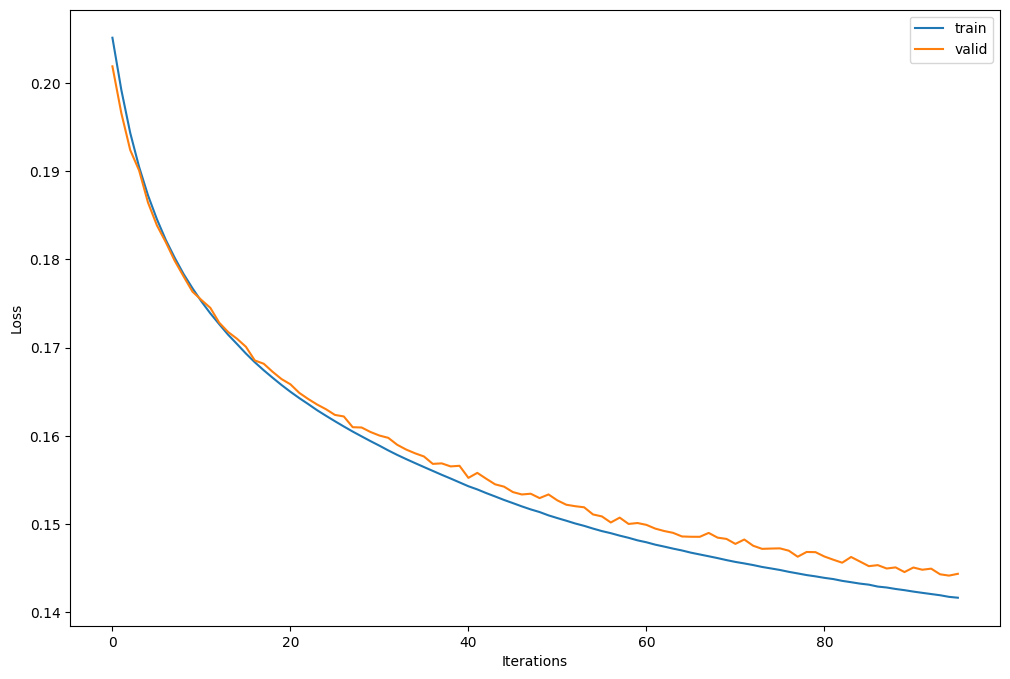

In [9]:
fig = plt.figure(figsize=(12, 8))

plt.plot(train_losses[4:], label='train')
plt.plot(valid_losses[4:], label='valid')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')

In [10]:
class ConvAutoEncoder(nn.Module):
    def __init__(self, img_shape, inp_dim, hidden_dim):
        super(ConvAutoEncoder, self).__init__()
        self.hidden_dim = hidden_dim

        self.enc_conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.enc_pool1 = nn.MaxPool2d(2, return_indices=True)
        
        self.enc_conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.enc_pool2 = nn.MaxPool2d(2, return_indices=True)
        
        self.enc_conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.enc_pool3 = nn.MaxPool2d(2, return_indices=True)
        
        self.flat = nn.Flatten()
        self.bottleneck_size = 128 * 3 * 3
        self.lin1 = nn.Linear(self.bottleneck_size, self.hidden_dim)
        
        self.lin2 = nn.Linear(self.hidden_dim, self.bottleneck_size)
        
        self.dec_conv1 = nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1)
        self.dec_conv2 = nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1)
        self.dec_conv3 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        
        self.dec_conv4 = nn.Conv2d(32, 1, 3, padding=3) 
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.enc_conv1(x))
        x, ind1 = self.enc_pool1(x)
        
        x = self.relu(self.enc_conv2(x))
        x, ind2 = self.enc_pool2(x)
        
        x = self.relu(self.enc_conv3(x))
        x, ind3 = self.enc_pool3(x)
        
        x = self.flat(x)
        x = self.lin1(x)
        
        x = self.lin2(x)
        x = x.view(-1, 128, 3, 3)
        
        x = self.relu(self.dec_conv1(x))
        x = self.relu(self.dec_conv2(x))
        x = self.relu(self.dec_conv3(x))
        
        x = self.dec_conv4(x)
        
        return x
    
    def decode(self, x) :
        x = self.lin2(x)
        x = x.view(-1, 128, 3, 3)
        
        x = self.relu(self.dec_conv1(x))
        x = self.relu(self.dec_conv2(x))
        x = self.relu(self.dec_conv3(x))
        
        x = self.dec_conv4(x)

        return x

In [11]:
modelconv = ConvAutoEncoder((1, 28, 28), 28*28, 8)
criterion = nn.MSELoss()
opt = optim.Adam(modelconv.parameters(), lr=0.001)

In [12]:
def train_step2() -> float:
    modelconv.train()
    
    running_loss = 0.
    for images, _ in train_loader:
        images = images.to(device)
        
        # Удаляем накопленные ранее градиенты.
        # parameter.grad = 0
        opt.zero_grad()
        
        # Делаем проход (forward pass).
        # Состояние модели `train` обеспечивает сохранение промежуточных результатов вычислений.
        # Эти сохраненные значения будут использованы ниже для вычисления градиента функции потерь.
        output = modelconv(images)
        
        # Вычисляем функцию потерь на основе предсказания модели.
        loss = criterion(output, images)

        # Вычисляем градиент: направление, в котором функция потерь возрастает максимально быстро.
        # parameter.grad += dloss / dparameter
        loss.backward()

        # parameter += -lr * parameter.grad
        # 
        # PyTorch SGD:
        # velocity = momentum * velocity + parameter.grad
        # parameter += - lr * velocity
        opt.step()
        
        # Накапливаем статистику.
        running_loss += loss
    
    # Контекстный менеджер `torch.no_grad` позволяет отключить вычисление градиентов.
    # Вычисления, в которые входят обучаемые параметры, не имеющие отношения к сети повлияют на процесс обучения,
    # если для них будут накапливаться градиенты.
    # Экономия памяти.
    with torch.no_grad():
        train_loss = running_loss / len(train_loader)
    return train_loss.item()


def test_step2() -> Tuple[float, float]:
    modelconv.eval()

    running_loss = 0.
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)

            output = modelconv(images)

            loss = criterion(output, images)
            running_loss += loss
        
    valid_loss = running_loss / len(test_loader)
    return valid_loss.item()

In [13]:


train_losses = []
valid_losses = []

epochs = 100
modelconv.to(device)

for _ in (pbar := tqdm(range(epochs))):
    train_loss = train_step2()
    valid_loss = test_step2()
    
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    
    pbar.set_description(f'Avg. train/valid loss: {train_loss:.4f}/{valid_loss:.4f}')


Avg. train/valid loss: 0.1275/0.1369: 100%|██████████| 100/100 [08:02<00:00,  4.83s/it]


Text(0, 0.5, 'Loss')

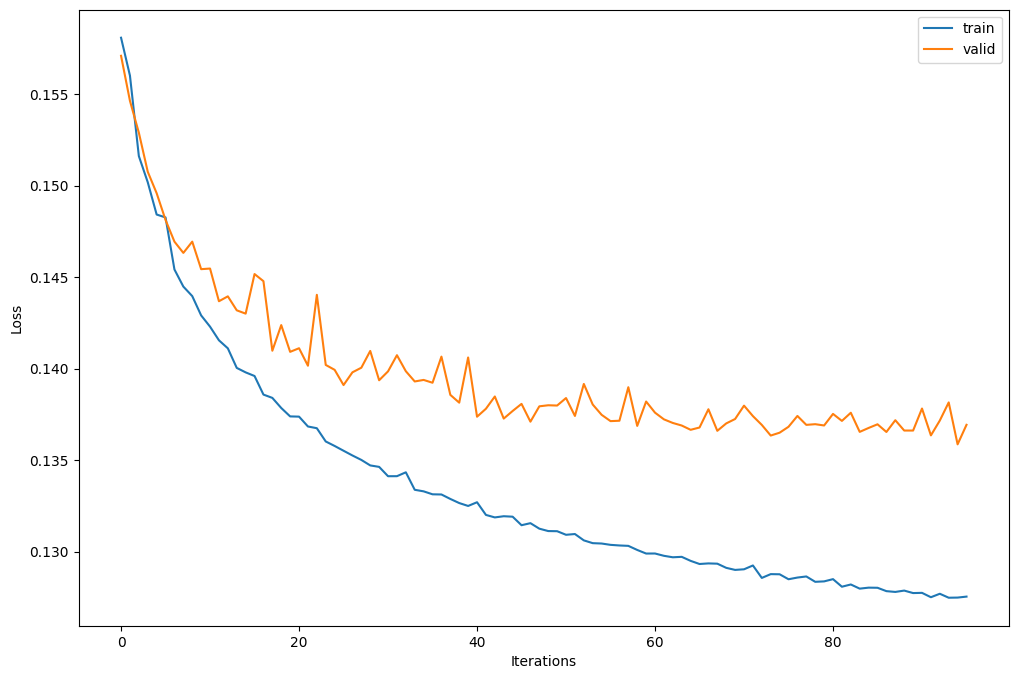

In [14]:
fig = plt.figure(figsize=(12, 8))

plt.plot(train_losses[4:], label='train')
plt.plot(valid_losses[4:], label='valid')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')

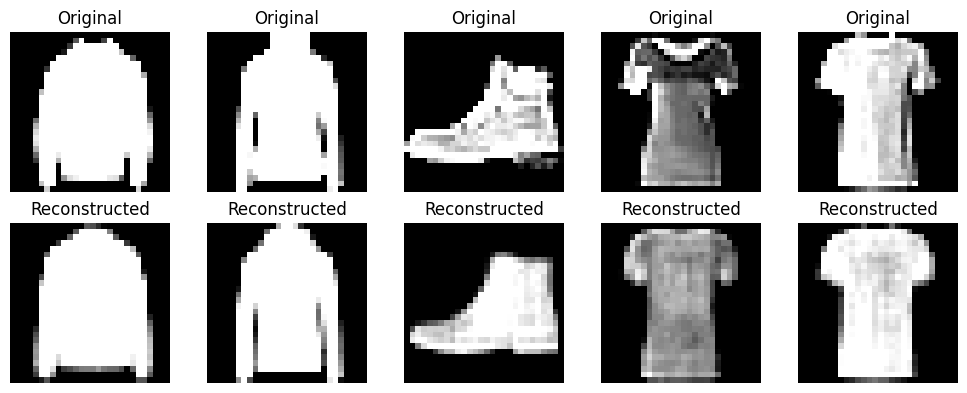

In [ ]:
def visualize_reconstructions(model, dataloader, device, n_images=5):
    model.eval()
    images, _ = next(iter(dataloader))
    images = images[:n_images].to(device)
    
    with torch.no_grad():
        reconstructions = model(images)
    
    comparison = torch.cat([images, reconstructions], dim=0)
    grid = comparison.cpu().clamp(0, 1)
    
    plt.figure(figsize=(10, 4))
    for i in range(len(grid)):
        plt.subplot(2, n_images, i + 1)
        plt.imshow(grid[i].squeeze(), cmap='gray')
        plt.axis('off')
        if i < n_images:
            plt.title('Original')
        else:
            plt.title('Reconstructed')
    plt.tight_layout()
    plt.show()

# Вызов после обучения
visualize_reconstructions(model, test_loader, device)

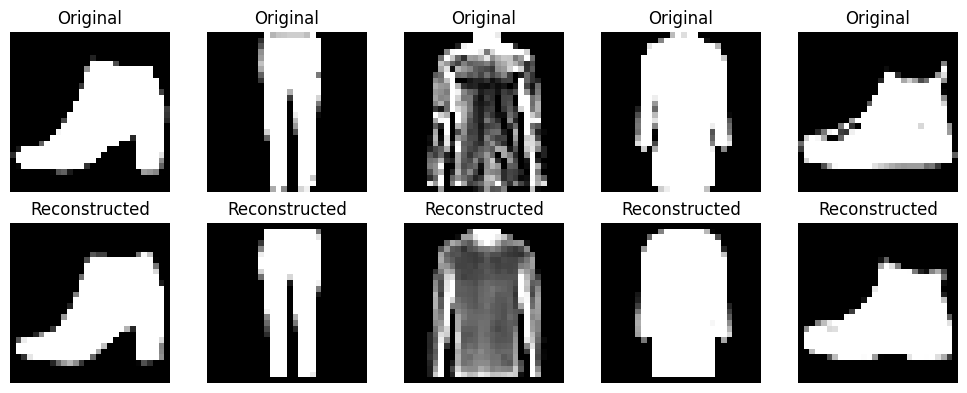

In [20]:
visualize_reconstructions(modelconv, test_loader, device)

In [ ]:
def plot(z1, z2, z3, z4, z5, z6, z7, z8):
    plt.figure(2)
    z = torch.Tensor([[z1, z2, z3, z4, z5, z6, z7, z8]]).to(device)
    with torch.no_grad():
        decoded = model.decode(z)
    img = decoded.reshape(28, 28).to('cpu').detach().numpy()
    plt.imshow(img, cmap='gray')
    plt.show()

model.eval()

interactive_plot = interactive(plot,
                               z1=(0., 1., 0.01),
                               z2=(0., 1., 0.01),
                               z3=(0., 1., 0.01),
                               z4=(0., 1., 0.01),
                               z5=(0., 1., 0.01),
                               z6=(0., 1., 0.01),
                               z7=(0., 1., 0.01),
                               z8=(0., 1., 0.01)
                    )


output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(FloatSlider(value=0.5, description='z1', max=1.0, step=0.01), FloatSlider(value=0.5, des…

In [18]:
def plot(z1, z2, z3, z4, z5, z6, z7, z8):
    plt.figure(2)
    z = torch.Tensor([[z1, z2, z3, z4, z5, z6, z7, z8]]).to(device)
    with torch.no_grad():
        decoded = modelconv.decode(z)
    img = decoded.reshape(28, 28).to('cpu').detach().numpy()
    plt.imshow(img, cmap='gray')
    plt.show()

modelconv.eval()

interactive_plot = interactive(plot,
                               z1=(0., 1., 0.01),
                               z2=(0., 1., 0.01),
                               z3=(0., 1., 0.01),
                               z4=(0., 1., 0.01),
                               z5=(0., 1., 0.01),
                               z6=(0., 1., 0.01),
                               z7=(0., 1., 0.01),
                               z8=(0., 1., 0.01)
                    )


output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(FloatSlider(value=0.5, description='z1', max=1.0, step=0.01), FloatSlider(value=0.5, des…

In [19]:
torch.save(model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(), 'model.pth')
torch.save(modelconv.module.state_dict() if isinstance(modelconv, nn.DataParallel) else modelconv.state_dict(), 'modelconv.pth')